In [1]:
# ============================================================
# CIRCLE DRAWING AND TRACING — MOTOR CONTROL ANALYSIS
# Author: Tuba Tuba
# Course: Python-R-Git | Supervisor: Denis MOTTET
# Scientific Question: Does faster execution come at the cost
# of reduced trajectory accuracy in circular movements?
# Does this tradeoff differ between drawing and tracing?
# ============================================================

# --- Import libraries ---
import os # to navigate the file paths
import glob # to find all CSV files matching a pattern
import numpy as np # for numerical operations
import pandas as pd # for data manipulation and analysis
import matplotlib.pyplot as plt # for plotting
import seaborn as sns # for cleaner statistical plots
from scipy.signal import savgol_filter # for smoothing trajectories

# --- Display settings ---
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')

In [2]:
# Step 1: PATH CONFIGURATION
ROOT_DIR = os.path.dirname(os.path.abspath("main.ipynb"))

# Build paths to data and results folders
DATA_DIR = os.path.join(ROOT_DIR, "data")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")

# Count and list all CSV files found in data folder
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print(f"\n Found {len(csv_files)} CSV files in data folder")

# Print each filename found (basename removes the full path)
for f in csv_files:
    print(f"   → {os.path.basename(f)}")


 Found 10 CSV files in data folder
   → subject_1_F_38_yrs_old_90_drawing.csv
   → subject_1_F_38_yrs_old_90_tracing.csv
   → subject_2_F_20_yrs_old_100_drawing.csv
   → subject_2_F_20_yrs_old_100_tracing.csv
   → subject_3_F_21_yrs_old_90_drawing.csv
   → subject_3_F_21_yrs_old_90_tracing.csv
   → subject_4_F_23_yrs_old_-20_drawing.csv
   → subject_4_F_23_yrs_old_-20_tracing.csv
   → subject_5_F_21_yrs_old_90_drawing.csv
   → subject_5_F_21_yrs_old_90_tracing.csv


In [3]:
# Step 3 — LOAD AND EXPLORE A SINGLE FILE
# Purpose: Before loading all files, we inspect one file
# to understand the data structure, column names, and values


# --- Load one drawing file as example ---
# We pick subject_1 drawing file to inspect
sample_draw_file = os.path.join(DATA_DIR, 
                    "subject_1_F_38_yrs_old_90_drawing.csv")

sample_trace_file = os.path.join(DATA_DIR, 
                    "subject_1_F_38_yrs_old_90_tracing.csv")

# Read the CSV file into a pandas DataFrame
df_draw_sample = pd.read_csv(sample_draw_file)
df_trace_sample = pd.read_csv(sample_trace_file)

# --- Inspect the drawing file ---
print("DRAWING FILE — subject_1")


# Show shape: (number of rows, number of columns)
# rows = number of data points recorded during movement
print(f"\n Shape (rows, columns): {df_draw_sample.shape}")

# Show column names
print(f"\n Columns: {list(df_draw_sample.columns)}")

# Show first 5 rows to understand what values look like
print(f"\n First 5 rows:")
print(df_draw_sample.head())

# Show basic statistics: mean, min, max of each column
print(f"\n Basic statistics:")
print(df_draw_sample.describe())

# --- Inspect the tracing file ---
print("TRACING FILE — subject_1")
print(f"\n Shape (rows, columns): {df_trace_sample.shape}")
print(f"\n Columns: {list(df_trace_sample.columns)}")
print(f"\n First 5 rows:")
print(df_trace_sample.head())
print(f"\n Basic statistics:")
print(df_trace_sample.describe())

# --- Compare the two files ---
print("QUICK COMPARISON — subject_1")

# The time column name is different for drawing and tracing
# drawing files use: prog_time_draw_sec
# tracing files use: prog_time_trace_sec
# Total movement time = the LAST value in the time column
# because time starts at 0 and ends at the last recorded point

mt_draw = df_draw_sample['prog_time_draw_sec'].iloc[-1]
mt_trace = df_trace_sample['prog_time_trace_sec'].iloc[-1]

print(f"\nMovement Time DRAWING : {mt_draw:.2f} seconds")
print(f"Movement Time TRACING : {mt_trace:.2f} seconds")
print(f"\nData points DRAWING   : {len(df_draw_sample)}")
print(f"Data points TRACING   : {len(df_trace_sample)}")

# Sampling rate = number of points divided by total time
# tells us how many measurements per second were recorded
sr_draw = len(df_draw_sample) / mt_draw
sr_trace = len(df_trace_sample) / mt_trace

print(f"\nSampling rate DRAWING : {sr_draw:.1f} Hz")
print(f"Sampling rate TRACING : {sr_trace:.1f} Hz")

DRAWING FILE — subject_1

 Shape (rows, columns): (154, 3)

 Columns: ['x', 'y', 'prog_time_draw_sec']

 First 5 rows:
           x         y  prog_time_draw_sec
0  24.040816  5.877551            0.000000
1  24.040816  5.857143            0.021612
2  24.040816  5.836735            0.043225
3  24.020408  5.836735            0.064837
4  24.000000  5.816327            0.086450

 Basic statistics:
                x           y  prog_time_draw_sec
count  154.000000  154.000000          154.000000
mean    24.294991    7.867347            1.653351
std      2.554957    2.565950            0.963916
min     19.591837    5.285714            0.000000
25%     22.801020    5.653061            0.826675
50%     24.040816    6.724490            1.653351
75%     26.520408   10.265306            2.480026
max     28.081633   12.510204            3.306701
TRACING FILE — subject_1

 Shape (rows, columns): (1544, 3)

 Columns: ['x', 'y', 'prog_time_trace_sec']

 First 5 rows:
           x         y  prog_tim

In [4]:
# Verify time always starts at 0
first_time_draw = df_draw_sample['prog_time_draw_sec'].iloc[0]
first_time_trace = df_trace_sample['prog_time_trace_sec'].iloc[0]

print(f"\nFirst time value DRAWING : {first_time_draw}")
print(f"First time value TRACING : {first_time_trace}")

# If both are 0.0 our assumption is confirmed
if first_time_draw == 0.0 and first_time_trace == 0.0:
    print("\nConfirmed: time starts at 0 in both files")
else:
    print("\nWarning: time does not start at 0 - needs investigation")


First time value DRAWING : 0.0
First time value TRACING : 0.0

Confirmed: time starts at 0 in both files


In [5]:

# CELL 4 — LOAD ALL FILES INTO ONE DATAFRAME
# Purpose: Read all drawing and tracing CSV files and combine
# them into a single organized table for analysis
# Each row = one subject, one task, with key metrics

# List to store data from each file
# We will append one row per file then convert to DataFrame
all_data = []

# Get all CSV files from data folder
all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print(f"Loading {len(all_files)} files...")

# Loop through each file one by one
for filepath in sorted(all_files):
    
    # Extract filename without the full path
    filename = os.path.basename(filepath)
    
    # Determine task type from filename
    # filename contains either "drawing" or "tracing"
    if "drawing" in filename:
        task = "drawing"
        time_col = "prog_time_draw_sec"
    else:
        task = "tracing"
        time_col = "prog_time_trace_sec"
    
    # Extract subject info from filename
    # filename format: subject_1_F_38_yrs_old_90_drawing.csv
    parts = filename.replace(".csv", "").split("_")
    subject_id = int(parts[1])       # subject number
    gender     = parts[2]            # F or M
    age        = int(parts[3])       # age in years
    laterality = int(parts[6])       # laterality score
    
    # Read the CSV file
    df = pd.read_csv(filepath)
    
    # Compute Movement Time (MT)
    # = last value of time column (time goes from 0 to end)
    mt = df[time_col].iloc[-1]
    
    # Compute number of data points (samples)
    n_points = len(df)
    
    # Compute sampling rate = samples / total time
    sampling_rate = n_points / mt
    
    # Store all info as one row in our list
    all_data.append({
        'subject_id'    : subject_id,
        'gender'        : gender,
        'age'           : age,
        'laterality'    : laterality,
        'task'          : task,
        'movement_time' : round(mt, 3),
        'n_points'      : n_points,
        'sampling_rate' : round(sampling_rate, 1),
        'filename'      : filename
    })

# Convert list of rows into a pandas DataFrame
df_main = pd.DataFrame(all_data)

# Sort by subject_id then task for clean display
df_main = df_main.sort_values(
                ['subject_id', 'task']).reset_index(drop=True)

# Display the master table
print("Master DataFrame created successfully!")
print(f"Shape: {df_main.shape}")
print(f"\n{df_main.to_string()}")

Loading 10 files...
Master DataFrame created successfully!
Shape: (10, 9)

   subject_id gender  age  laterality     task  movement_time  n_points  sampling_rate                                filename
0           1      F   38          90  drawing          3.307       154           46.6   subject_1_F_38_yrs_old_90_drawing.csv
1           1      F   38          90  tracing         39.194      1544           39.4   subject_1_F_38_yrs_old_90_tracing.csv
2           2      F   20         100  drawing          2.167       122           56.3  subject_2_F_20_yrs_old_100_drawing.csv
3           2      F   20         100  tracing         15.254       876           57.4  subject_2_F_20_yrs_old_100_tracing.csv
4           3      F   21          90  drawing          4.374       227           51.9   subject_3_F_21_yrs_old_90_drawing.csv
5           3      F   21          90  tracing          9.940       531           53.4   subject_3_F_21_yrs_old_90_tracing.csv
6           4      F   23         -2

In [6]:
# ============================================================
# CELL 5 — DEFINE RMSE FUNCTION
# Purpose: Create a reusable function to measure accuracy
# of circular movements
#
# What is RMSE here?
# Each movement should be a perfect circle
# We measure how far each point deviates from a perfect circle
#
# Steps inside the function:
# 1. Smooth the raw x,y coordinates (remove pen tablet noise)
# 2. Find the center of the movement (mean x, mean y)
# 3. Compute radius from center to each point
# 4. RMSE = deviation of each radius from the mean radius
#
# Low RMSE = movement close to perfect circle = high accuracy
# High RMSE = irregular shape = low accuracy
# ============================================================

def compute_rmse(filepath, task):
    
    # Read the CSV file into a DataFrame
    df = pd.read_csv(filepath)
    
    # Extract x and y coordinates as numpy arrays
    # numpy arrays are faster for mathematical operations
    x = df['x'].values
    y = df['y'].values
    
    # Determine correct time column based on task
    # drawing files use prog_time_draw_sec
    # tracing files use prog_time_trace_sec
    if task == 'drawing':
        time_col = 'prog_time_draw_sec'
    else:
        time_col = 'prog_time_trace_sec'
    
    # Step 1: Smooth x and y using Savitzky-Golay filter
    # This filter removes noise while preserving movement shape
    # window_length=11: number of points used for smoothing
    # polyorder=3: degree of polynomial fit (cubic)
    # We need at least 11 points to apply the filter
    if len(x) > 11:
        x_smooth = savgol_filter(x, window_length=11, polyorder=3)
        y_smooth = savgol_filter(y, window_length=11, polyorder=3)
    else:
        # Too few points — use raw data without smoothing
        x_smooth = x
        y_smooth = y
    
    # Step 2: Find center of the trajectory
    # Geometric center = average of all x and y positions
    cx = np.mean(x_smooth)
    cy = np.mean(y_smooth)
    
    # Step 3: Compute radius at each time point
    # Distance from center to each (x,y) point
    # Pythagorean theorem: r = sqrt((x-cx)^2 + (y-cy)^2)
    radii = np.sqrt((x_smooth - cx)**2 + (y_smooth - cy)**2)
    
    # Step 4: Mean radius = best estimate of circle size
    mean_radius = np.mean(radii)
    
    # Step 5: Compute RMSE
    # How much do individual radii deviate from mean radius?
    # sqrt(mean of squared differences)
    rmse = np.sqrt(np.mean((radii - mean_radius)**2))
    
    # Return both values rounded to 4 decimal places
    return round(rmse, 4), round(mean_radius, 4)

# Confirm function is defined and ready
print("compute_rmse() function defined successfully")

compute_rmse() function defined successfully


In [7]:
# CELL 6 — APPLY RMSE TO ALL FILES
# Purpose: Loop through all CSV files and compute RMSE
# and mean radius for each subject and task
# We call the compute_rmse() function we defined in Cell 5


# Empty lists to store results
# We will fill these as we loop through each file
rmse_list   = []
radius_list = []

# Get all CSV files from data folder
all_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

print("Computing RMSE for all files...")
print("=" * 60)

# Loop through each file
for filepath in all_files:
    
    # Get just the filename without the full path
    filename = os.path.basename(filepath)
        # Determine task type from filename
    task = "drawing" if "drawing" in filename else "tracing"
    
    # Call our compute_rmse function from Cell 5
    # Returns two values: rmse and mean_radius
    rmse, mean_radius = compute_rmse(filepath, task)
    
    # Store results in our lists
    rmse_list.append(rmse)
    radius_list.append(mean_radius)
    
    # Print result for this file
    print(f"{filename:55s} | "
          f"RMSE: {rmse:.4f} cm | "
          f"Radius: {mean_radius:.4f} cm")


Computing RMSE for all files...
subject_1_F_38_yrs_old_90_drawing.csv                   | RMSE: 1.0524 cm | Radius: 3.4518 cm
subject_1_F_38_yrs_old_90_tracing.csv                   | RMSE: 0.2381 cm | Radius: 5.0895 cm
subject_2_F_20_yrs_old_100_drawing.csv                  | RMSE: 0.4921 cm | Radius: 1.6642 cm
subject_2_F_20_yrs_old_100_tracing.csv                  | RMSE: 0.4425 cm | Radius: 5.0196 cm
subject_3_F_21_yrs_old_90_drawing.csv                   | RMSE: 0.5632 cm | Radius: 2.0704 cm
subject_3_F_21_yrs_old_90_tracing.csv                   | RMSE: 0.8435 cm | Radius: 4.9779 cm
subject_4_F_23_yrs_old_-20_drawing.csv                  | RMSE: 1.4743 cm | Radius: 6.6615 cm
subject_4_F_23_yrs_old_-20_tracing.csv                  | RMSE: 0.2735 cm | Radius: 5.0846 cm
subject_5_F_21_yrs_old_90_drawing.csv                   | RMSE: 0.5035 cm | Radius: 2.0737 cm
subject_5_F_21_yrs_old_90_tracing.csv                   | RMSE: 0.2170 cm | Radius: 5.0685 cm


In [8]:
# CELL 7 — UPDATE DATAFRAME WITH RMSE
# Purpose: Add the RMSE and mean radius values we computed
# in Cell 6 into our DataFrame from Cell 4
# This gives us one complete table with all metrics:
# subject info + movement time + accuracy (RMSE)

# Add RMSE list as a new column in DataFrame
# The order matches because we looped through sorted files
# in both Cell 4 and Cell 6
df_main['rmse'] = rmse_list
df_main['mean_radius'] = radius_list

# Display the complete main DataFrame
print("Main DataFrame updated successfully!")
print("=" * 60)
print(f"Shape: {df_main.shape} "
      f"({df_main.shape[0]} rows, "
      f"{df_main.shape[1]} columns)")
print("=" * 60)

# Show only the most important columns for clarity
print("\nComplete results table:")
print(df_main[['subject_id', 
                  'task',
                  'movement_time',
                  'rmse',
                  'mean_radius']].to_string())

# ---- Quick summary statistics ----
print("Quick summary by task:")

# Group by task and compute mean of key metrics
# This gives us a first look at drawing vs tracing differences
summary = df_main.groupby('task')[
    ['movement_time', 'rmse', 'mean_radius']
].agg(['mean', 'std']).round(3)

print(summary)

# Save main DataFrame to results folder
# So we have a clean CSV of all computed metrics
output_path = os.path.join(RESULTS_DIR, "main_results.csv")
df_main.to_csv(output_path, index=False)
print(f"\nMain results saved to: {output_path}")

Main DataFrame updated successfully!
Shape: (10, 11) (10 rows, 11 columns)

Complete results table:
   subject_id     task  movement_time    rmse  mean_radius
0           1  drawing          3.307  1.0524       3.4518
1           1  tracing         39.194  0.2381       5.0895
2           2  drawing          2.167  0.4921       1.6642
3           2  tracing         15.254  0.4425       5.0196
4           3  drawing          4.374  0.5632       2.0704
5           3  tracing          9.940  0.8435       4.9779
6           4  drawing          3.471  1.4743       6.6615
7           4  tracing         34.609  0.2735       5.0846
8           5  drawing          6.247  0.5035       2.0737
9           5  tracing         32.579  0.2170       5.0685
Quick summary by task:
        movement_time           rmse        mean_radius       
                 mean     std   mean    std        mean    std
task                                                          
drawing         3.913   1.522  0.817  0

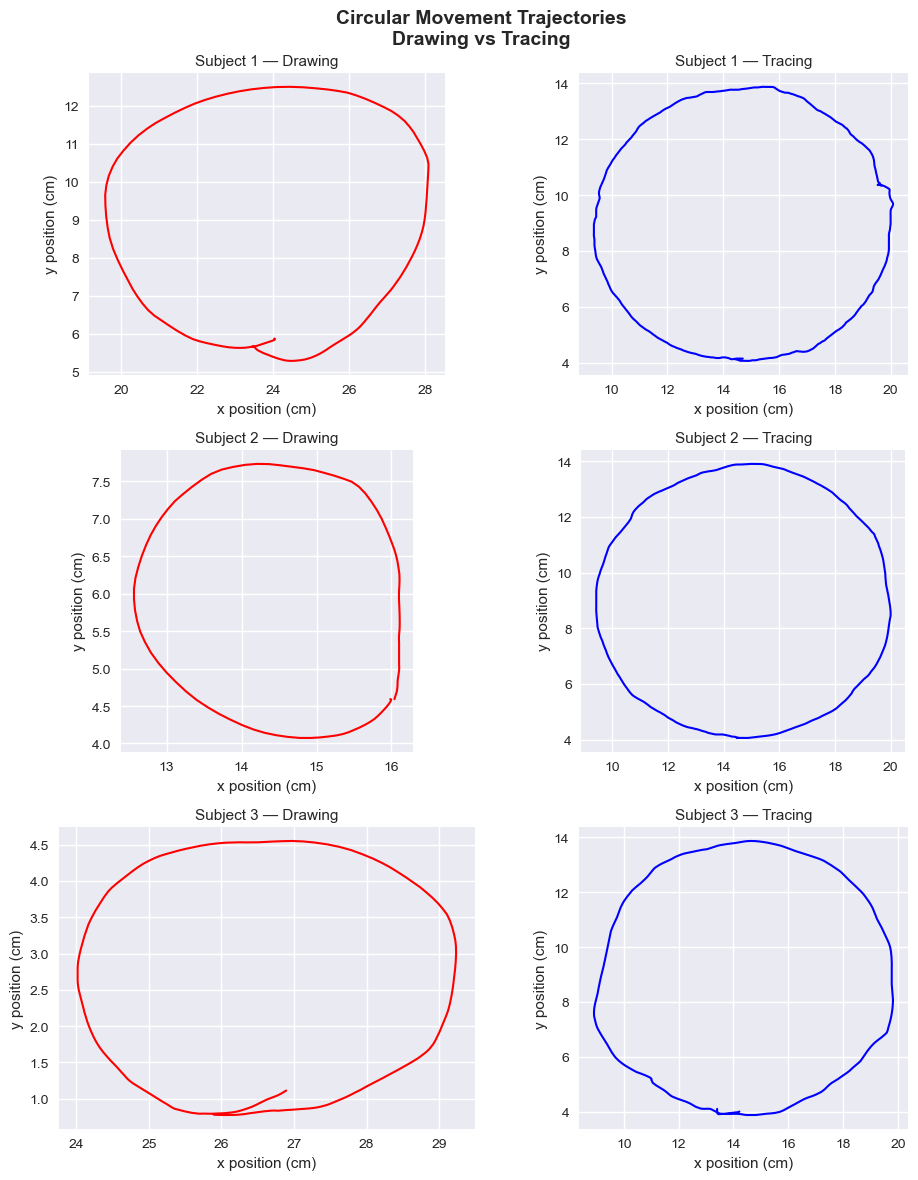

Trajectory plot saved to: c:\Users\hrman\OneDrive\Desktop\data_analysis_project\tuba.tuba\results\trajectories.png


In [10]:
# ============================================================
# CELL 8 — TRAJECTORY VISUALIZATION
# Purpose: Plot actual circular trajectories for drawing
# and tracing side by side for 3 subjects
# Files are found automatically from df_main
# no hardcoded filenames
# ============================================================

# Select first 3 subject IDs from our main DataFrame
subjects_to_plot = [1, 2, 3]

# Create figure with 3 rows and 2 columns
# Each row = one subject
# Left column = drawing, Right column = tracing
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
fig.suptitle(
    "Circular Movement Trajectories\nDrawing vs Tracing",
    fontsize=14, fontweight='bold')

for i, subj in enumerate(subjects_to_plot):

    # Find the actual filename for this subject from df_main
    # This avoids hardcoding filenames
    draw_filename = df_main[
        (df_main['subject_id'] == subj) &
        (df_main['task'] == 'drawing')
    ]['filename'].values[0]

    trace_filename = df_main[
        (df_main['subject_id'] == subj) &
        (df_main['task'] == 'tracing')
    ]['filename'].values[0]

    # Build full file paths
    draw_file  = os.path.join(DATA_DIR, draw_filename)
    trace_file = os.path.join(DATA_DIR, trace_filename)

    # Read CSV files
    df_draw  = pd.read_csv(draw_file)
    df_trace = pd.read_csv(trace_file)

    # Smooth trajectories using Savitzky-Golay filter
    # Removes pen tablet noise while preserving shape
    x_draw  = savgol_filter(df_draw['x'].values,
                            window_length=11, polyorder=3)
    y_draw  = savgol_filter(df_draw['y'].values,
                            window_length=11, polyorder=3)
    x_trace = savgol_filter(df_trace['x'].values,
                            window_length=11, polyorder=3)
    y_trace = savgol_filter(df_trace['y'].values,
                            window_length=11, polyorder=3)

    # Plot drawing trajectory — left column
    # Red color for drawing (internal guidance)
    axes[i, 0].plot(x_draw, y_draw,
                    color='red', linewidth=1.5)
    axes[i, 0].set_title(f"Subject {subj} — Drawing",
                          fontsize=11)
    axes[i, 0].set_xlabel("x position (cm)")
    axes[i, 0].set_ylabel("y position (cm)")
    axes[i, 0].set_aspect('equal')

    # Plot tracing trajectory — right column
    # Blue color for tracing (external guidance)
    axes[i, 1].plot(x_trace, y_trace,
                    color='blue', linewidth=1.5)
    axes[i, 1].set_title(f"Subject {subj} — Tracing",
                          fontsize=11)
    axes[i, 1].set_xlabel("x position (cm)")
    axes[i, 1].set_ylabel("y position (cm)")
    axes[i, 1].set_aspect('equal')

# Adjust spacing between subplots
plt.tight_layout()

# Save figure to results folder
output_fig = os.path.join(RESULTS_DIR, "trajectories.png")
plt.savefig(output_fig, dpi=150, bbox_inches='tight')
plt.show()

print(f"Trajectory plot saved to: {output_fig}")

C:\Users\hrman\AppData\Local\Temp\ipykernel_20720\317218490.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([draw_mt, trace_mt],


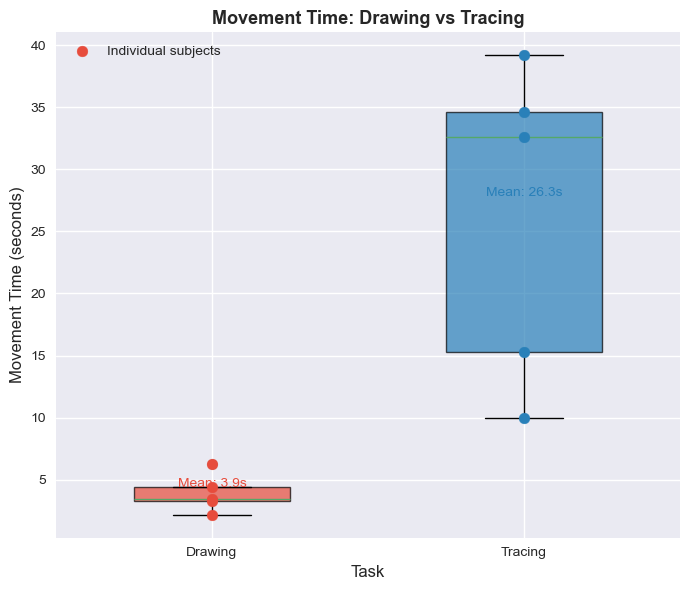

Movement time box plot saved to: c:\Users\hrman\OneDrive\Desktop\data_analysis_project\tuba.tuba\results\movement_time_boxplot.png

Drawing  MT — Mean: 3.91s  Std: 1.52s
Tracing  MT — Mean: 26.32s  Std: 12.89s


In [11]:
# CELL 9 — MOVEMENT TIME BOX PLOT
# Purpose: Visually compare movement time between
# drawing and tracing tasks
# Box plot shows median, spread and outliers
# This directly answers: "is tracing slower than drawing?"

fig, ax = plt.subplots(figsize=(7, 6))

# Define colors for each task
# Red for drawing, Blue for tracing
# consistent with trajectory plot colors
colors = {'drawing': '#e74c3c', 'tracing': '#2980b9'}

# Separate movement time values by task
draw_mt  = df_main[df_main['task'] == 'drawing']['movement_time']
trace_mt = df_main[df_main['task'] == 'tracing']['movement_time']

# Create box plot
# patch_artist=True fills the boxes with color
bp = ax.boxplot([draw_mt, trace_mt],
                labels=['Drawing', 'Tracing'],
                patch_artist=True,
                widths=0.5)

# Apply colors to boxes
bp['boxes'][0].set_facecolor(colors['drawing'])
bp['boxes'][1].set_facecolor(colors['tracing'])

# Set transparency so colors are not too strong
for patch in bp['boxes']:
    patch.set_alpha(0.7)

# Add individual data points on top of box plot
# This shows actual values since we have few subjects
ax.scatter(
    [1] * len(draw_mt),
    draw_mt,
    color=colors['drawing'],
    zorder=3,
    s=60,
    label='Individual subjects'
)
ax.scatter(
    [2] * len(trace_mt),
    trace_mt,
    color=colors['tracing'],
    zorder=3,
    s=60
)

# Labels and title
ax.set_title("Movement Time: Drawing vs Tracing",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Task", fontsize=12)
ax.set_ylabel("Movement Time (seconds)", fontsize=12)
ax.legend(fontsize=10)

# Add mean values as text on plot
ax.text(1, draw_mt.mean() + 0.5,
        f"Mean: {draw_mt.mean():.1f}s",
        ha='center', fontsize=10, color=colors['drawing'])
ax.text(2, trace_mt.mean() + 1.5,
        f"Mean: {trace_mt.mean():.1f}s",
        ha='center', fontsize=10, color=colors['tracing'])

plt.tight_layout()

# Save to results folder
output_fig = os.path.join(RESULTS_DIR, "movement_time_boxplot.png")
plt.savefig(output_fig, dpi=150, bbox_inches='tight')
plt.show()

print(f"Movement time box plot saved to: {output_fig}")
print(f"\nDrawing  MT — Mean: {draw_mt.mean():.2f}s  "
      f"Std: {draw_mt.std():.2f}s")
print(f"Tracing  MT — Mean: {trace_mt.mean():.2f}s  "
      f"Std: {trace_mt.std():.2f}s")